# 골연령 예측 — **Xception 단독 (전처리 X · Bilinear X)** : 논문 Ablation 대조군

> Zhang, Wu, Zhou & Li, *Uncertainty-aware multi-stream deep learning for pediatric orthopedic bone age assessment from hand radiographs* (JKSU-CIS, 2026)
>
> **표 5 (a)행 재현** — `Xception, no preproc.` → 논문 보고값 **MAE 5.12개월**
> `USE_PREPROC = True` 로 바꾸면 **표 5 (b)행** `Xception + preproc.` → 논문 보고값 **MAE 4.45개월**

---

## 이 노트북의 목적 (읽고 시작하세요)

성능을 내려는 모델이 아니라 **대조군(control)** 입니다.
최종모델(InceptionV3 + Bilinear)이 논문 수치에 못 미칠 때 **원인이 어디에 있는지 반으로 가르는 것**이 유일한 목적입니다.

| 이 노트북의 결과 | 해석 | 다음 조치 |
|---|---|---|
| MAE **5.0 ~ 5.5** | 데이터·학습루프 정상 → **Bilinear 헤드가 문제** | v2의 외적 스케일 `/(h*w)`, sign-sqrt/ℓ2, 1×1 Conv 뒤 BN·ReLU 점검 |
| MAE **6 ~ 8** | **학습 레시피 문제** | 에폭 수(≥30), 타깃 z-정규화, L1 손실, 백본 fine-tune, 증강 |
| MAE **> 15** | **데이터/라벨 버그** | 검증셋 컬럼명·성별 코드·μ/σ 역변환 점검 |
| MAE **≈ 33** | 학습이 아예 안 됨 | 백본 freeze / LR / 타깃 스케일 폭주 |

> ⚠ **공정한 비교의 전제**: 논문은 *"All variants are trained ... using the same data split, preprocessing pipeline, and optimization schedule"* 라고 명시합니다.
> **§6 하이퍼파라미터 셀을 v2(최종모델) 노트북과 반드시 동일하게** 맞추세요. 여기서 값이 다르면 대조군으로서 무의미해집니다.

---

## 논문 대비 구조 (§3.4 · 식 13~17 · 그림 4)

```
X-ray (Grayscale → 3ch)
   └─ Xception backbone (ImageNet, top 제거)      → F ∈ R^(h×w×2048)
        └─ Conv 3×3, 256 filters (padding=same)
             └─ MaxPool 3×3, stride 3
                  └─ Flatten                      → z ∈ R^d      (논문: 9,216)
성별 g (0/1)
   └─ Dense(32)                                   → e ∈ R^32     (Xception 계열은 k=32)
                  └─ concat [z ; e] → Dense(1)    → 골연령(개월)
```

**의도적으로 빠진 것**: 전처리(크롭·평활화) · Bilinear pooling · 불확실성 분기. 그게 이 대조군의 요점입니다.


## 0. 환경 확인 및 의존성

In [1]:
# Xception은 torchvision에 없습니다 → timm 필요 (최초 1회만)
# !pip install timm
import os, sys, math, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

try:
    import timm
    print("timm       :", timm.__version__)
except ImportError:
    raise SystemExit("timm이 없습니다.  ->  pip install timm  후 커널 재시작")

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))
    print("CUDA ver   :", torch.version.cuda)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# [RTX 5060 = Blackwell, sm_120] CUDA available=False 이거나 'no kernel image' 오류 시:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

timm       : 1.0.28
Python     : 3.11.9
PyTorch    : 2.12.0.dev20260408+cu128
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU
CUDA ver   : 12.8
device     : cuda


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True       # 속도 우선
torch.backends.cudnn.deterministic = False  # 완전 재현이 필요하면 True/False 반전

### 0-1. 한글 경로 대응 이미지 I/O
Windows에서 `cv2.imread`는 한글 경로에 대해 조용히 `None`을 반환합니다. 아래를 항상 사용하세요.

In [3]:
def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    # 한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.
    try:
        buf = np.fromfile(str(path), dtype=np.uint8)
        return cv2.imdecode(buf, flags)
    except Exception:
        return None

def imwrite_kr(path, img):
    # 한글/유니코드 경로에도 저장 가능한 이미지 쓰기.
    path = str(path)
    ext = os.path.splitext(path)[1] or ".png"
    ok, buf = cv2.imencode(ext, img)
    if ok:
        buf.tofile(path)
    return ok

print("한글 경로 I/O 준비 완료")

한글 경로 I/O 준비 완료


## 1. CONFIG

**딱 하나의 스위치가 이 노트북의 정체를 결정합니다.**

| 스위치 | 값 | 재현 대상 | 논문 보고 MAE |
|---|---|---|---|
| `USE_PREPROC` | **`False`** (기본) | 표5 **(a)** Xception, no preproc. | **5.12** |
| `USE_PREPROC` | `True` | 표5 **(b)** Xception + preproc. | **4.45** |

두 번 돌려서 **차이가 0.6~0.7개월** 나오면 → 전처리 파이프라인이 논문대로 작동한다는 강력한 증거입니다.
(논문: *"reduces MAE by 0.67 months (from 5.12 to 4.45), representing the largest single-factor improvement"*)

In [4]:
# ==================== 경로 (v2 노트북과 동일하게 맞추세요) ====================
DATA_ROOT  = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터")  # <- 본인 경로로 수정
TRAIN_CSV  = DATA_ROOT / "Bone+Age+Training+Set+Annotations" / "train.csv"
TRAIN_DIR  = DATA_ROOT / "Bone+Age+Training+Set" / "boneage-training-dataset"
VAL_CSV    = DATA_ROOT / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "Validation Dataset.csv"
VAL_DIR    = DATA_ROOT / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "boneage-validation-dataset-1"

OUTPUT_DIR = DATA_ROOT / "outputs_xception_ablation"    # 모든 산출물이 여기로
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ==================== 실험 스위치 ====================
USE_PREPROC = False        # * False = 표5(a) 대조군(5.12) / True = 표5(b) (4.45)
IMG_SIZE    = 512          # 논문 §3.4 Entry Flow 기준. 608이면 논문의 z=9,216 차원과 정확히 일치
CACHE       = True         # 리사이즈 결과를 디스크에 캐싱(2회차부터 학습 속도 대폭 향상)

TAG       = ("prep" if USE_PREPROC else "raw") + str(IMG_SIZE)
CACHE_DIR = OUTPUT_DIR / ("cache_" + TAG)
(CACHE_DIR / "train").mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "val").mkdir(parents=True, exist_ok=True)

REF_MAE = 4.45 if USE_PREPROC else 5.12                 # 논문 표5 보고값
ROW     = "(b) Xception + preproc." if USE_PREPROC else "(a) Xception, no preproc."

print(f"[CONFIG] USE_PREPROC={USE_PREPROC}  IMG_SIZE={IMG_SIZE}  TAG={TAG}")
print(f"[CONFIG] 재현 대상: 논문 표5 {ROW}  ->  보고 MAE {REF_MAE} 개월")
print(f"[CONFIG] OUTPUT_DIR = {OUTPUT_DIR}")

[CONFIG] USE_PREPROC=False  IMG_SIZE=512  TAG=raw512
[CONFIG] 재현 대상: 논문 표5 (a) Xception, no preproc.  ->  보고 MAE 5.12 개월
[CONFIG] OUTPUT_DIR = C:\Users\Win11Pro\Desktop\뼈데이터\outputs_xception_ablation


## 2. 데이터 로드 (공식 분할 그대로)

RSNA 공식 분할: **train 12,611 / validation 1,425 / test 200**.
논문의 4.10·5.12·4.45는 모두 **validation 1,425장 기준**입니다(표6의 `Overall N=1425`가 근거).

CSV 컬럼명이 train/validation에서 다릅니다 (`id` vs `Image ID`, `boneage` vs `Bone Age (months)`).
**여기서 조용히 틀리는 재현 실패가 매우 흔합니다** → 자동 탐지 + 성별 코드 정규화를 넣었습니다.

In [5]:
def load_split(csv_path, img_dir):
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}

    def pick(*cands):
        for c in cands:
            if c in cols:
                return cols[c]
        raise KeyError(f"컬럼을 찾을 수 없습니다: {cands} / 실제 컬럼={list(df.columns)}")

    c_id   = pick("id", "image id", "case id", "imageid")
    c_age  = pick("boneage", "bone age (months)", "bone age", "boneage(months)")
    c_male = pick("male", "gender", "sex")

    out = pd.DataFrame({
        "id":   df[c_id].astype(int),
        "age":  df[c_age].astype(float),      # 개월 단위
        "male": df[c_male],
    })

    def to_male(v):
        # True/'TRUE'/'M'/1 -> 1.0,  False/'F'/0 -> 0.0
        if isinstance(v, (bool, np.bool_)):
            return float(v)
        if isinstance(v, (int, float, np.integer, np.floating)):
            return float(int(v) != 0)
        s = str(v).strip().lower()
        if s in ("true", "t", "m", "male", "1"):
            return 1.0
        if s in ("false", "f", "w", "female", "0"):
            return 0.0
        raise ValueError(f"알 수 없는 성별 값: {v!r}")

    out["male"] = out["male"].map(to_male)
    out["path"] = out["id"].map(lambda i: str(Path(img_dir) / f"{i}.png"))

    missing = [p for p in out["path"].head(200) if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(f"이미지 경로 확인 필요. 예: {missing[0]}")
    return out


tr = load_split(TRAIN_CSV, TRAIN_DIR)
va = load_split(VAL_CSV,   VAL_DIR)

print(f"train {len(tr):,}장 | val {len(va):,}장   (논문: 12,611 / 1,425)")
print(f"train age  mean={tr.age.mean():.1f}  std={tr.age.std():.1f}  "
      f"min={tr.age.min():.0f}  max={tr.age.max():.0f} (months)")
print(f"train male ratio={tr.male.mean():.3f}   val male ratio={va.male.mean():.3f}")

# ---- 무학습 기준선: 학습 후 MAE가 이 근처면 모델이 이미지를 전혀 못 읽는 것 ----
print()
print(f"[기준선] 전체 평균 예측 MAE = {np.abs(va.age - tr.age.mean()).mean():.2f} 개월")
mu_m, mu_f = tr[tr.male == 1].age.mean(), tr[tr.male == 0].age.mean()
pred_g = np.where(va.male.values == 1, mu_m, mu_f)
print(f"[기준선] 성별 평균 예측 MAE = {np.abs(va.age.values - pred_g).mean():.2f} 개월")

train 12,611장 | val 1,425장   (논문: 12,611 / 1,425)
train age  mean=127.3  std=41.2  min=1  max=228 (months)
train male ratio=0.542   val male ratio=0.542

[기준선] 전체 평균 예측 MAE = 33.99 개월
[기준선] 성별 평균 예측 MAE = 32.72 개월


## 3. 전처리 — OFF(대조군) vs ON

**`USE_PREPROC = False` (기본, 표5 a행)**
논문의 "no preproc." 조건 = **크롭 없음 · 평활화 없음**. 원본 PNG를 정사각 리사이즈만 합니다.
→ 배경 패딩·노출 편차·손 위치 편차가 그대로 모델에 들어갑니다. 이게 **5.12개월의 정체**입니다.

**`USE_PREPROC = True` (표5 b행)** — 논문 표8의 3단계
1. **ROI Extraction**: 흑백 변환 + 자동 바운딩박스 크롭
2. **Rescaling**: 고정 입력 크기로 리사이즈
3. **Normalization**: 히스토그램 평활화 (`cv2.equalizeHist`)

> ⚠ 여기 크롭은 **논문 표8 수준의 기본형(Otsu + 최대 연결요소)** 입니다.
> 카세트 판·번인 글자 케이스까지 처리하려면 v4 노트북의 `rescue` 모드를 그대로 이식하세요.
> 다만 **대조군의 목적상 v2와 동일한 전처리 함수를 쓰는 것이 원칙**입니다.

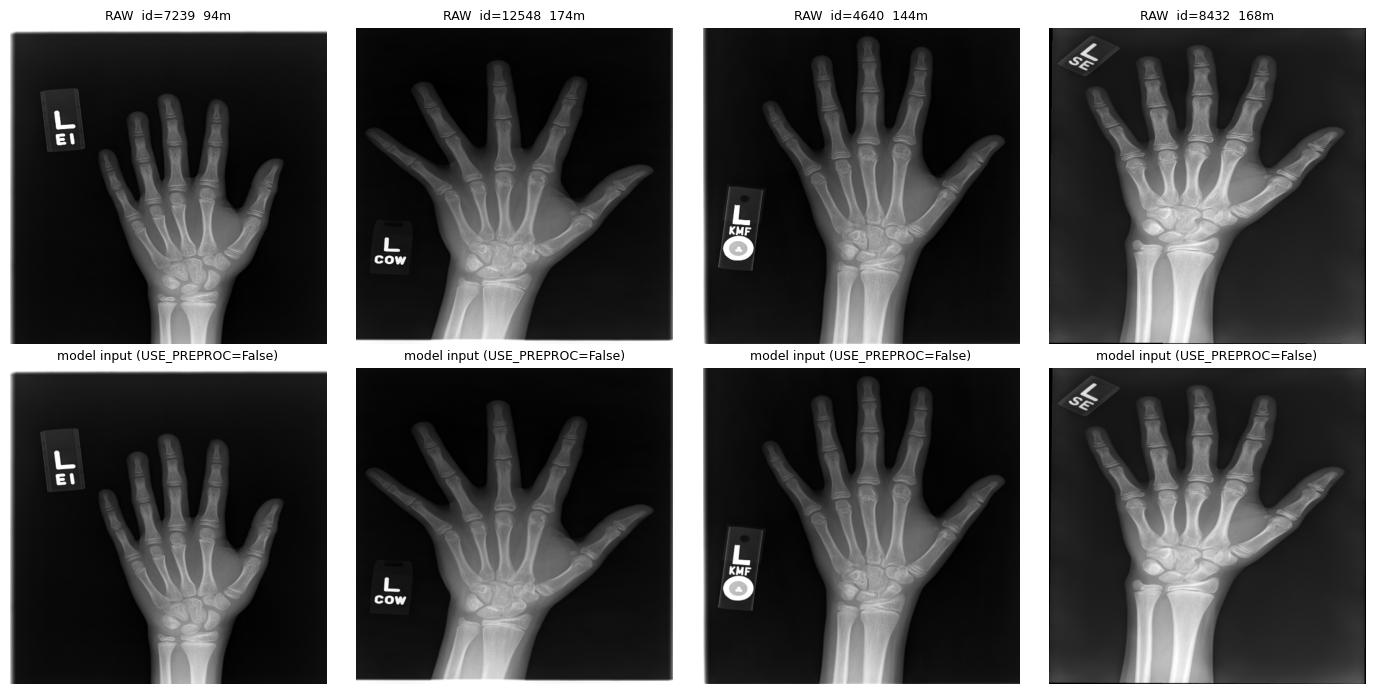

In [6]:
def crop_hand_bbox(g, work=768):
    # Otsu + 최대 연결요소 -> 손 bbox 크롭 (논문 표8 1단계의 기본형)
    h0, w0 = g.shape
    s = work / max(h0, w0)
    small = cv2.resize(g, (int(w0 * s), int(h0 * s)), interpolation=cv2.INTER_AREA) if s < 1 else g.copy()

    blur = cv2.GaussianBlur(small, (5, 5), 0)
    _, bw = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN,  np.ones((5, 5), np.uint8))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    n, lab, stats, _ = cv2.connectedComponentsWithStats(bw, 8)
    if n <= 1:
        return g                                     # 실패 시 원본 반환(안전)
    k = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    x, y, w, h, area = stats[k]
    if area < 0.02 * small.size:                     # 너무 작으면 신뢰 불가
        return g

    inv = (1.0 / s) if s < 1 else 1.0
    x, y, w, h = [int(v * inv) for v in (x, y, w, h)]
    pad = int(0.02 * max(w, h))
    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1, y1 = min(w0, x + w + pad), min(h0, y + h + pad)
    return g[y0:y1, x0:x1]


def preprocess(g, use_preproc=None, size=None):
    # grayscale ndarray -> (size, size) uint8.  use_preproc=False면 리사이즈만.
    use_preproc = USE_PREPROC if use_preproc is None else use_preproc
    size = IMG_SIZE if size is None else size

    if use_preproc:
        g = crop_hand_bbox(g)                                          # (1) ROI
        g = cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA)  # (2) Rescale
        g = cv2.equalizeHist(g)                                        # (3) Normalize
    else:
        g = cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA)  # 리사이즈만
    return g


# ---- 육안 확인 (4장) ----
sample = tr.sample(4, random_state=0)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, (_, r) in enumerate(sample.iterrows()):
    g = imread_kr(r["path"])
    axes[0, j].imshow(cv2.resize(g, (IMG_SIZE, IMG_SIZE)), cmap="gray")
    axes[0, j].set_title(f"RAW  id={r['id']}  {r['age']:.0f}m", fontsize=9)
    axes[1, j].imshow(preprocess(g), cmap="gray")
    axes[1, j].set_title(f"model input (USE_PREPROC={USE_PREPROC})", fontsize=9)
    axes[0, j].axis("off"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

## 4. 캐시 + Dataset / DataLoader

원본 PNG는 장당 2~3MB라 매 에폭 디코딩하면 GPU가 놉니다. 리사이즈 결과를 한 번만 PNG로 캐싱합니다.
`TAG`에 `USE_PREPROC`·`IMG_SIZE`가 들어가므로 **설정을 바꾸면 캐시가 자동으로 분리**됩니다.

In [7]:
def build_cache(df, split):
    out_dir = CACHE_DIR / split
    todo = [(int(r["id"]), r["path"]) for _, r in df.iterrows()
            if not (out_dir / f"{int(r['id'])}.png").exists()]
    if not todo:
        print(f"[cache] {split}: 이미 완료 ({len(df):,}장)")
        return
    fail = []
    for i, p in tqdm(todo, desc=f"cache/{split}"):
        g = imread_kr(p)
        if g is None:
            fail.append(i); continue
        imwrite_kr(out_dir / f"{i}.png", preprocess(g))
    print(f"[cache] {split}: {len(todo):,}장 처리, 실패 {len(fail)}건 {fail[:5]}")


if CACHE:
    build_cache(tr, "train")
    build_cache(va, "val")

[cache] train: 이미 완료 (12,611장)
[cache] val: 이미 완료 (1,425장)


In [8]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class BoneAgeDS(Dataset):
    def __init__(self, df, split, train=False, aug=True):
        self.df = df.reset_index(drop=True)
        self.split, self.train, self.aug = split, train, aug

    def __len__(self):
        return len(self.df)

    def _load(self, r):
        if CACHE:
            g = imread_kr(CACHE_DIR / self.split / f"{int(r['id'])}.png")
            if g is not None:
                return g
        return preprocess(imread_kr(r["path"]))

    def _augment(self, g):
        # 논문에 증강 명시는 없으나, 미증강 시 12.6k장에서 빠르게 과적합합니다.
        # * v2 노트북과 반드시 동일하게 유지하세요 (다르면 대조군으로서 무의미).
        h, w = g.shape
        ang    = np.random.uniform(-15, 15)
        scale  = np.random.uniform(0.90, 1.10)
        tx, ty = np.random.uniform(-0.05, 0.05, 2) * w
        M = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), ang, scale)
        M[0, 2] += tx; M[1, 2] += ty
        g = cv2.warpAffine(g, M, (w, h), flags=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        if np.random.rand() < 0.5:
            g = cv2.flip(g, 1)                                          # 좌우반전
        a = np.random.uniform(0.9, 1.1)
        b = np.random.uniform(-10, 10)                                  # 밝기/대비
        g = np.clip(g.astype(np.float32) * a + b, 0, 255).astype(np.uint8)
        return g

    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = self._load(r)
        if self.train and self.aug:
            g = self._augment(g)
        x = np.repeat(g[:, :, None], 3, axis=2).astype(np.float32) / 255.0   # 1ch -> 3ch
        x = (x - IMAGENET_MEAN) / IMAGENET_STD                               # ImageNet 정규화
        x = torch.from_numpy(x.transpose(2, 0, 1).copy())
        gd = torch.tensor([r["male"]], dtype=torch.float32)
        y  = torch.tensor(r["age"], dtype=torch.float32)
        return x, gd, y


print("Dataset 정의 완료")

Dataset 정의 완료


## 5. 모델 — Xception + 3×3 Conv(256) + 3×3 MaxPool(stride 3) + 성별 임베딩(k=32)

논문 §3.4 식 (13)~(17) 그대로입니다.

$$\mathbf{z}=\mathrm{Flat}\big(\mathrm{MaxPool}_{3\times3}(\mathrm{Conv}_{3\times3}(\mathbf{F}))\big),\qquad
\mathbf{e}=\phi_\psi(g)\in\mathbb{R}^{32},\qquad
\hat{y}=\mathbf{w}^\top[\mathbf{z};\mathbf{e}]+b$$

- **Bilinear 없음** — 최종모델과 갈리는 유일한 구조적 지점입니다.
- 논문의 `z ∈ R^9216` (= 6×6×256)은 백본 출력이 19×19일 때 나옵니다 → `IMG_SIZE = 608`.
  그 외 크기에서는 **flatten 차원을 자동 계산**하므로 그대로 두어도 동작합니다.
- `Conv`/`Dense(32)`의 활성함수는 논문에 명시가 없어 ReLU를 기본으로 두되 플래그로 뺐습니다.

In [9]:
def make_xception_backbone():
    # timm에서 원조 Xception(Chollet) 백본을 특징맵 형태로 생성
    last_err = None
    for name in ("legacy_xception", "xception"):
        try:
            m = timm.create_model(name, pretrained=True, num_classes=0, global_pool="")
            print(f"[backbone] timm '{name}' 로드 완료")
            return m
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Xception 백본 생성 실패: {last_err}")


class XceptionRegressor(nn.Module):
    # 논문 §3.4 Xception regression baseline (전처리/Bilinear/불확실성 전부 없음)
    def __init__(self, img_size=512, head_relu=True, gender_relu=True, gender_dim=32):
        super().__init__()
        self.backbone = make_xception_backbone()

        with torch.no_grad():                            # 백본 출력 채널/해상도 자동 탐지
            f = self.backbone(torch.zeros(1, 3, img_size, img_size))
        c, h, w = f.shape[1], f.shape[2], f.shape[3]

        self.conv = nn.Conv2d(c, 256, kernel_size=3, padding=1)   # padding='same'
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)         # floor 연산
        self.head_relu = head_relu

        with torch.no_grad():
            z = self.pool(self.conv(f))
        self.feat_dim = int(z.numel())

        self.gender      = nn.Linear(1, gender_dim)
        self.gender_relu = gender_relu
        self.fc          = nn.Linear(self.feat_dim + gender_dim, 1)   # 선형 회귀 1개

        n_par = sum(p.numel() for p in self.parameters()) / 1e6
        print(f"[model] backbone out = {c}x{h}x{w}  ->  z dim = {self.feat_dim:,}"
              f"   (논문 9,216 = IMG_SIZE 608일 때)")
        print(f"[model] total params = {n_par:.1f}M   (논문 표4: 22.9M)")

    def forward(self, x, g):
        f = self.backbone(x)
        z = self.conv(f)
        if self.head_relu:
            z = F.relu(z)
        z = torch.flatten(self.pool(z), 1)
        e = self.gender(g)
        if self.gender_relu:
            e = F.relu(e)
        return self.fc(torch.cat([z, e], dim=1)).squeeze(1)


# ---- 스모크 테스트 ----
_m = XceptionRegressor(img_size=IMG_SIZE).to(device)
with torch.no_grad():
    _y = _m(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=device),
            torch.zeros(2, 1, device=device))
print("[smoke] output shape =", tuple(_y.shape))
del _m
torch.cuda.empty_cache()

[backbone] timm 'legacy_xception' 로드 완료
[model] backbone out = 2048x16x16  ->  z dim = 6,400   (논문 9,216 = IMG_SIZE 608일 때)
[model] total params = 25.5M   (논문 표4: 22.9M)
[smoke] output shape = (2,)


## 6. 하이퍼파라미터 + **논문 충실도 스위치**

### 6-A. 논문에 실제로 적혀 있는 것 / 없는 것

| 항목 | 논문 | 비고 |
|---|---|---|
| 구조(백본·Conv3×3 256·MaxPool3×3 s3·Flatten·성별 k=32·Linear) | **명시** §3.4 식(13)~(17) | 그대로 구현 |
| 전처리 3단계 | **명시** 표8 | 그대로 구현 |
| 에폭 = 30 | 그림 8에서 확인 | 고정 30 (얼리스탑 없음) |
| 손실 함수 | **없음** | L1로 가정 (평가지표가 MAE) |
| 옵티마이저·LR·배치 | **없음** (Algorithm 1에 Adam만) | 제 선택 |
| 타깃 정규화 | **없음** (개월 단위 직접 회귀) | 제 추가 |
| 데이터 증강 | **없음** | 제 추가 |
| Warmup·얼리스탑 | **없음** | 제 추가 |
| Conv/Dense 활성함수 | **없음** (Keras 기본 = linear) | 제 선택 |

### 6-B. `PAPER_STRICT` 스위치

- **`PAPER_STRICT = True`** → 논문에 적힌 것만 사용
  (증강 OFF · 타깃정규화 OFF · warmup 0 · 얼리스탑 OFF · 30에폭 고정 · 활성함수 linear · 단일 LR)
  → **논문 텍스트에 가장 충실**하지만, 개월 단위(μ≈127) 직접 회귀 + 대형 헤드라 **초기 발산 위험**이 있습니다.
- **`PAPER_STRICT = False`** (기본) → 재현 가능성을 높인 실전 레시피.
  **v2(최종모델)와 이 셀 값을 반드시 동일하게** 맞추세요. 다르면 대조군으로서 무의미합니다.

> **권장**: 먼저 `False`로 돌려 파이프라인이 정상인지 확인하고, 그다음 `True`로 논문 조건을 검증하세요.
> 두 결과의 차이 자체가 "논문이 생략한 레시피가 얼마나 기여하는가"에 대한 답이 됩니다.

### 6-C. 얼리스탑 위치
- **정의**: 이 셀의 `EARLY_STOP` · `PATIENCE`
- **동작**: 다음 셀 §7 `train()` 함수의 에폭 루프 마지막 `if bad >= PATIENCE: break`

In [10]:
# ==================== 논문 충실도 스위치 ====================
PAPER_STRICT = False        # True = 논문에 적힌 것만 (증강/정규화/warmup/얼리스탑 전부 OFF)

# ==================== 학습 레시피 ====================
EPOCHS          = 100        # 논문 그림 8 = 30에폭
BATCH           = 16        # OOM이면 8로 낮추고 ACCUM=2 (유효 배치 유지)
ACCUM           = 1
LR_BACKBONE     = 1e-4      # 사전학습 백본은 낮게
LR_HEAD         = 1e-3      # 새 헤드는 높게
WEIGHT_DECAY    = 1e-4
WARMUP_EPOCHS   = 1         # 1에폭은 헤드만 학습 (논문에 없음)
FREEZE_BACKBONE = False     # True로 두면 절대 논문 수치 안 나옵니다
LOSS            = "l1"      # "l1" | "huber"   (논문 미명시)
HUBER_DELTA     = 5.0
TARGET_NORM     = True      # z-정규화 후 회귀 -> 평가 시 역변환 (논문에 없음)
AUG             = True      # 데이터 증강 (논문에 없음)
HEAD_RELU       = True      # Conv3x3 뒤 ReLU (논문 미명시)
GENDER_RELU     = True      # Dense(32) 뒤 ReLU (논문 미명시)
COSINE          = True      # LR 스케줄 (논문 미명시)
AMP             = True
NUM_WORKERS     = 0         # Windows에서 문제가 있으면 0

# ==================== 얼리스탑 (논문에는 없음) ====================
EARLY_STOP = True           # False면 EPOCHS까지 무조건 완주 (논문 조건)
PATIENCE   = 15              # val MAE가 PATIENCE 에폭 연속 개선 없으면 중단
                            # -> 실제 중단 로직은 다음 셀 train() 안의 'if bad >= PATIENCE: break'

# ==================== STRICT 모드 오버라이드 ====================
if PAPER_STRICT:
    AUG           = False   # 논문에 증강 언급 없음
    TARGET_NORM   = False   # 논문은 개월 단위 직접 회귀 (식 17)
    WARMUP_EPOCHS = 0       # 논문에 warmup 없음
    EARLY_STOP    = False   # 논문은 30에폭 고정 (그림 8)
    HEAD_RELU     = False   # Keras Conv2D/Dense 기본 = linear
    GENDER_RELU   = False
    COSINE        = False   # 고정 LR
    LR_HEAD       = LR_BACKBONE = 1e-4
    print("[PAPER_STRICT] 논문 명시 조건만 사용 — 증강/정규화/warmup/얼리스탑 OFF")
    print("[PAPER_STRICT] 주의: 개월 단위 직접 회귀라 초기 loss가 100+ 에서 시작합니다.")
    print("[PAPER_STRICT] 논문의 z=9,216 차원과 정확히 맞추려면 IMG_SIZE=608 로 두세요.")

# 타깃 정규화 통계는 train에서만 계산 (누수 방지)
AGE_MU, AGE_SD = float(tr.age.mean()), float(tr.age.std())
print(f"AGE_MU={AGE_MU:.3f}  AGE_SD={AGE_SD:.3f}  (TARGET_NORM={TARGET_NORM})")
print(f"EARLY_STOP={EARLY_STOP}  PATIENCE={PATIENCE}")

CFG = dict(arch="xception_baseline_no_bilinear", paper_row=ROW, ref_mae=REF_MAE,
           paper_strict=PAPER_STRICT, use_preproc=USE_PREPROC, img_size=IMG_SIZE,
           epochs=EPOCHS, batch=BATCH, lr_backbone=LR_BACKBONE, lr_head=LR_HEAD,
           weight_decay=WEIGHT_DECAY, loss=LOSS, target_norm=TARGET_NORM, aug=AUG,
           head_relu=HEAD_RELU, gender_relu=GENDER_RELU, cosine=COSINE,
           early_stop=EARLY_STOP, patience=PATIENCE, seed=SEED,
           age_mu=AGE_MU, age_sd=AGE_SD)
print(json.dumps(CFG, ensure_ascii=False, indent=2))

AGE_MU=127.321  AGE_SD=41.182  (TARGET_NORM=True)
EARLY_STOP=True  PATIENCE=15
{
  "arch": "xception_baseline_no_bilinear",
  "paper_row": "(a) Xception, no preproc.",
  "ref_mae": 5.12,
  "paper_strict": false,
  "use_preproc": false,
  "img_size": 512,
  "epochs": 100,
  "batch": 16,
  "lr_backbone": 0.0001,
  "lr_head": 0.001,
  "weight_decay": 0.0001,
  "loss": "l1",
  "target_norm": true,
  "aug": true,
  "head_relu": true,
  "gender_relu": true,
  "cosine": true,
  "early_stop": true,
  "patience": 15,
  "seed": 42,
  "age_mu": 127.3207517246848,
  "age_sd": 41.18202139939633
}


### 6-1. (선택·강력추천) 과적합 새니티 체크 — 3분

**본 학습 전에 반드시 한 번.** 200장만 증강 없이 반복 학습해서 **train MAE < 2개월**로 떨어지면
"데이터·라벨·모델·역전파"가 모두 정상이라는 뜻입니다.
여기서 안 떨어지면 **본 학습은 무조건 실패**하므로, 30에폭을 낭비하기 전에 여기서 잡으세요.

In [11]:
def sanity_overfit(n=200, steps=150):
    sub = tr.sample(n, random_state=0)
    dl  = DataLoader(BoneAgeDS(sub, "train", train=False),   # 증강 OFF
                     batch_size=8, shuffle=True, num_workers=0)
    m      = XceptionRegressor(img_size=IMG_SIZE, head_relu=HEAD_RELU,
                               gender_relu=GENDER_RELU).to(device)
    opt    = torch.optim.AdamW(m.parameters(), lr=3e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)

    m.train(); it = iter(dl); losses = []
    for _ in tqdm(range(steps), desc="sanity overfit"):
        try:
            x, g, y = next(it)
        except StopIteration:
            it = iter(dl); x, g, y = next(it)
        x, g, y = x.to(device), g.to(device), y.to(device)
        t = (y - AGE_MU) / AGE_SD if TARGET_NORM else y
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=AMP):
            loss = F.l1_loss(m(x, g), t)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        losses.append(loss.item() * (AGE_SD if TARGET_NORM else 1.0))

    print()
    print(f"최근 20스텝 평균 train MAE = {np.mean(losses[-20:]):.2f} 개월")
    print("  < 2.0  -> 파이프라인 정상. 본 학습으로 진행하세요.")
    print("  > 10   -> 데이터/라벨/정규화 버그. 본 학습해도 시간 낭비입니다.")
    del m; torch.cuda.empty_cache()
    return losses


# sanity_overfit()   # <- 주석 해제 후 1회 실행 권장

## 7. 학습 루프

- **Warmup 1에폭**: 헤드만 학습(백본 동결) → 대형 헤드의 랜덤 그래디언트가 사전학습 가중치를 망가뜨리는 것 방지
- **Cosine 스케줄** + **파라미터 그룹별 LR** (백본 1e-4 / 헤드 1e-3)
- **`best_*.pt`**: 가중치 + CONFIG + 정규화 통계(μ, σ)를 **한 파일에 자기완결적으로** 저장 → 추론 시 이 파일만 있으면 됨

In [ ]:
def make_loaders():
    dl_tr = DataLoader(BoneAgeDS(tr, "train", train=True, aug=AUG),
                       batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                       pin_memory=True, drop_last=True,
                       persistent_workers=NUM_WORKERS > 0)
    dl_va = DataLoader(BoneAgeDS(va, "val", train=False),
                       batch_size=BATCH * 2, shuffle=False, num_workers=NUM_WORKERS,
                       pin_memory=True, persistent_workers=NUM_WORKERS > 0)
    return dl_tr, dl_va


def criterion(pred, target):
    if LOSS == "huber":
        d = HUBER_DELTA / (AGE_SD if TARGET_NORM else 1.0)
        return F.huber_loss(pred, target, delta=d)
    return F.l1_loss(pred, target)


@torch.no_grad()
def evaluate(model, loader):
    model.eval(); P, Y = [], []
    for x, g, y in loader:
        x = x.to(device, non_blocking=True)
        g = g.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=AMP):
            p = model(x, g).float()
        if TARGET_NORM:
            p = p * AGE_SD + AGE_MU
        P.append(p.cpu().numpy()); Y.append(y.numpy())
    P = np.concatenate(P); Y = np.concatenate(Y)
    return float(np.abs(P - Y).mean()), P, Y


def train():
    dl_tr, dl_va = make_loaders()
    model = XceptionRegressor(img_size=IMG_SIZE, head_relu=HEAD_RELU,
                              gender_relu=GENDER_RELU).to(device)

    bb_params   = [p for n, p in model.named_parameters() if n.startswith("backbone")]
    head_params = [p for n, p in model.named_parameters() if not n.startswith("backbone")]
    opt = torch.optim.AdamW(
        [{"params": bb_params,   "lr": LR_BACKBONE},
         {"params": head_params, "lr": LR_HEAD}],
        weight_decay=WEIGHT_DECAY)
    sched  = (torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * len(dl_tr))
              if COSINE else None)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)

    hist, best, bad = [], float("inf"), 0
    ckpt = OUTPUT_DIR / f"best_xception_{TAG}.pt"

    for ep in range(1, EPOCHS + 1):
        frozen = FREEZE_BACKBONE or (ep <= WARMUP_EPOCHS)
        for p in bb_params:
            p.requires_grad_(not frozen)

        model.train(); run, n = 0.0, 0
        tag = " [bb frozen]" if frozen else ""
        pbar = tqdm(dl_tr, desc=f"ep {ep:02d}/{EPOCHS}{tag}")
        opt.zero_grad(set_to_none=True)

        for i, (x, g, y) in enumerate(pbar):
            x = x.to(device, non_blocking=True)
            g = g.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            t = (y - AGE_MU) / AGE_SD if TARGET_NORM else y

            with torch.amp.autocast("cuda", enabled=AMP):
                loss = criterion(model(x, g), t) / ACCUM
            scaler.scale(loss).backward()
            if (i + 1) % ACCUM == 0:
                scaler.step(opt); scaler.update()
                opt.zero_grad(set_to_none=True)
            if sched is not None:
                sched.step()

            run += loss.item() * ACCUM * x.size(0); n += x.size(0)
            pbar.set_postfix(train_mae=f"{run / n * (AGE_SD if TARGET_NORM else 1):.2f}")

        tr_mae = run / n * (AGE_SD if TARGET_NORM else 1)
        va_mae, _, _ = evaluate(model, dl_va)
        hist.append({"epoch": ep, "train_mae": tr_mae, "val_mae": va_mae})
        star = "   * best" if va_mae < best else ""
        print(f"  -> train MAE {tr_mae:6.2f} | val MAE {va_mae:6.2f} 개월{star}")

        if va_mae < best - 1e-4:
            best, bad = va_mae, 0
            torch.save({"model": model.state_dict(), "config": CFG,
                        "age_mu": AGE_MU, "age_sd": AGE_SD,
                        "val_mae": best, "epoch": ep}, ckpt)
        else:
            bad += 1
            # ===================== 얼리스탑 (논문에는 없음) =====================
            if EARLY_STOP and bad >= PATIENCE:
                print(f"[early stop] val MAE가 {PATIENCE}에폭 연속 개선 없음 -> ep {ep}에서 중단")
                break
            # ==================================================================

    pd.DataFrame(hist).to_csv(OUTPUT_DIR / f"history_{TAG}.csv", index=False)
    print()
    print(f"=== best val MAE = {best:.2f} 개월   (저장: {ckpt.name}) ===")
    return model, pd.DataFrame(hist), best, ckpt


model, hist, best_mae, ckpt_path = train()

[backbone] timm 'legacy_xception' 로드 완료
[model] backbone out = 2048x16x16  ->  z dim = 6,400   (논문 9,216 = IMG_SIZE 608일 때)
[model] total params = 25.5M   (논문 표4: 22.9M)


ep 01/100 [bb frozen]:   0%|          | 0/788 [00:00<?, ?it/s]

  -> train MAE  19.24 | val MAE  15.31 개월   * best


ep 02/100:   0%|          | 0/788 [00:00<?, ?it/s]

  -> train MAE  11.77 | val MAE   8.78 개월   * best


...

ep 12/100:   0%|          | 0/788 [00:00<?, ?it/s]

  -> train MAE   6.85 | val MAE   7.06 개월   * best


ep 13/100:   0%|          | 0/788 [00:00<?, ?it/s]

  -> train MAE   6.80 | val MAE   8.01 개월


ep 14/100:   0%|          | 0/788 [00:00<?, ?it/s]

## 8. 학습 곡선 (논문 그림 8 대응)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist.epoch, hist.train_mae, "o-", label="train MAE", alpha=0.7)
plt.plot(hist.epoch, hist.val_mae,   "s-", label="val MAE",   lw=2)
plt.axhline(REF_MAE, ls="--", c="r", label=f"paper Table5 {ROW[:3]} = {REF_MAE} months")
plt.xlabel("Training Epoch"); plt.ylabel("MAE (months)")
plt.title(f"Xception baseline  (USE_PREPROC={USE_PREPROC}, IMG_SIZE={IMG_SIZE})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"curve_{TAG}.png", dpi=140)
plt.show()

## 9. 최종 평가 + 연령대별 오차 (논문 표6 형식)

In [ ]:
best = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(best["model"])
_, dl_va = make_loaders()
mae, P, Y = evaluate(model, dl_va)

print(f"[최종] validation MAE = {mae:.2f} 개월   (N={len(Y)})")
print(f"[논문] 표5 {ROW} = {REF_MAE} 개월")
print(f"[차이] {mae - REF_MAE:+.2f} 개월")
print()

bins = [(0, 48, "0-4 yrs"), (48, 96, "4-8 yrs"), (96, 144, "8-12 yrs"),
        (144, 192, "12-16 yrs"), (192, 10 ** 4, ">16 yrs")]
rows = []
for lo, hi, name in bins:
    m = (Y >= lo) & (Y < hi)
    if m.sum() == 0:
        continue
    rows.append({"Age group": name, "N": int(m.sum()),
                 "MAE":  round(float(np.abs(P[m] - Y[m]).mean()), 2),
                 "Bias": round(float((P[m] - Y[m]).mean()), 2),
                 "SD":   round(float((P[m] - Y[m]).std()), 2)})
rows.append({"Age group": "Overall", "N": int(len(Y)),
             "MAE":  round(mae, 2),
             "Bias": round(float((P - Y).mean()), 2),
             "SD":   round(float((P - Y).std()), 2)})

tbl = pd.DataFrame(rows)
tbl.to_csv(OUTPUT_DIR / f"age_stratified_{TAG}.csv", index=False)
display(tbl)

np.save(OUTPUT_DIR / f"pred_{TAG}.npy", np.stack([Y, P]))   # v2 예측과 상관 비교용

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
lim = [0, float(max(Y.max(), P.max())) + 10]
ax[0].scatter(Y, P, s=6, alpha=0.35)
ax[0].plot(lim, lim, "r--"); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("Ground truth (months)"); ax[0].set_ylabel("Prediction (months)")
ax[0].set_title(f"Pred vs GT   (MAE={mae:.2f})"); ax[0].grid(alpha=0.3)
ax[1].hist(P - Y, bins=50); ax[1].axvline(0, c="r", ls="--")
ax[1].set_xlabel("Error = pred - GT (months)"); ax[1].set_title("Error distribution")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / f"scatter_{TAG}.png", dpi=140)
plt.show()

## 10. 진단 결론 (자동 판정)

이 셀의 출력이 **이 노트북의 최종 산출물**입니다. 나온 문장을 그대로 다음 작업의 근거로 쓰세요.

In [ ]:
print("=" * 74)
print(f"  대조군 결과: val MAE = {mae:.2f} 개월     (논문 표5 {ROW} = {REF_MAE})")
print("=" * 74)

if mae <= REF_MAE + 0.5:
    print('''
[OK] 데이터·학습루프 정상 (논문 재현 성공 범위)

  -> 문제는 Bilinear 헤드에 국한됩니다. v2에서 다음을 순서대로 점검하세요:
     1) 외적 스케일:  B = (X^T X) / (h*w)      <- '/(h*w)' 누락이 1순위 버그
     2) sign-sqrt + L2 정규화를 ON/OFF 둘 다 실측
        (논문은 "차이 <=0.02"라 생략했다지만, 재현 환경에서는 효과가 큰 경우가 많음)
     3) 1x1 Conv(2048->512->128) 뒤 BN/ReLU 유무
     4) Bilinear 헤드에 dropout이 걸려 있으면 제거 후 재측정
''')
elif mae <= REF_MAE + 2.0:
    print('''
[WARN] 학습 레시피 미달 (구조 문제 아님)

  -> 위에서부터 하나씩 적용하며 재측정:
     1) EPOCHS >= 30 (그림 8 기준 20에폭 이후 plateau)
     2) TARGET_NORM = True 확인
     3) FREEZE_BACKBONE = False 확인
     4) AUG ON, cosine 스케줄
     5) IMG_SIZE 299 -> 480/512 로 상향
''')
else:
    print('''
[FAIL] 데이터/라벨 레벨 버그 의심

  -> 6-1의 sanity_overfit() 부터 실행하세요. train MAE가 2 이하로 안 떨어지면:
     1) 검증셋 CSV 컬럼 매핑 (Image ID / Bone Age (months) / male)
     2) 성별 코드 True/False <-> 1/0 변환
     3) AGE_MU / AGE_SD 역변환 (evaluate에서 p*SD+MU)
     4) 이미지가 실제로 손 X-ray인지 육안 확인 (3절 미리보기)
''')

print("[다음 실험] USE_PREPROC 를 반대로 바꿔 한 번 더 실행하세요.")
print("           (a) 5.12  <->  (b) 4.45  의 0.67개월 차이가 재현되면,")
print("           전처리 파이프라인이 논문대로 작동한다는 강력한 증거입니다.")